# Q-Learning with OpenAI

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import gymnasium as gym

import io

from IPython.display import display, clear_output
import random


In [4]:
# Making the Taxi environment
env = gym.make("Taxi-v3", render_mode="rgb_array")

In [5]:
# Showing the observation at the start what the agent sees at the start.
obs, info = env.reset(seed = 42)
print(f"observation: {obs} \ninfo {info}")

observation: 386 
info {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)}


In [6]:
possible_actions = env.action_space
observations = env.observation_space
print(f"{possible_actions} means that the possible actions are integers 0 to 5.")
print(f"{observations} means that the observation space is 0 to 499")


Discrete(6) means that the possible actions are integers 0 to 5.
Discrete(500) means that the observation space is 0 to 499


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


<bound method TimeLimit.reset of <TimeLimit<OrderEnforcing<PassiveEnvChecker<TaxiEnv<Taxi-v3>>>>>>

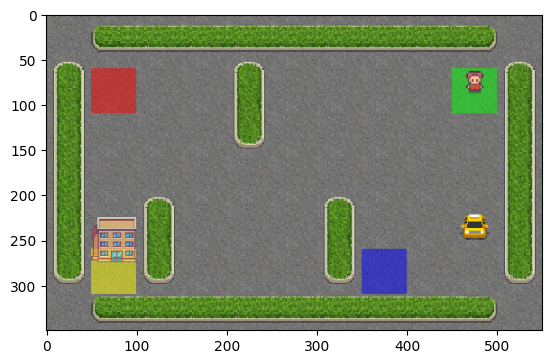

In [7]:
# Showing the taxi and enviornment
img = env.render()
plt.imshow(env.render())
img.shape
env.reset

Observation: 286 
Reward:-1, 
Done:False, 
Truncated: False, 
Info: 
{'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)}


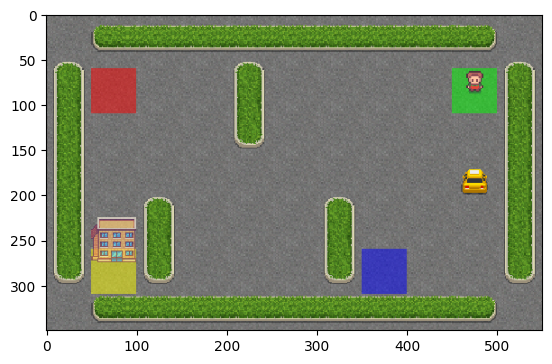

In [8]:
# lets say we take an action of 1 to move up we can see where the agent ends up. 
action = 1
obs, reward, done, truncated, info= env.step(action)
plt.imshow(env.render())
print(f"Observation: {obs} \nReward:{reward}, \nDone:{done}, \nTruncated: {truncated}, \nInfo: \n{info}")

In [29]:
# Initalizing Q
q_table = np.zeros([env.observation_space.n, env.action_space.n])
# episodes times we will are trianing
episodes = 1100
# rate of exploration
epsilon = 0.1
epsilon_decay = 0.8
min_epsilon = 0.01
# how much future rewards are valued
gamma = 0.5
# learning rate
alpha = 0.2
# when the agent has reached terminal state
done = True 

In [30]:
state_size = env.observation_space.n
action_size = env.action_space.n
q_table = np.zeros((state_size, action_size))


# rewards list
training_rewards = []

# Training Loop
for episode in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0
    while not done:
        # epsilon greedy
        if random.uniform(0, 1) < epsilon:
            # Random
            action = env.action_space.sample()
        else:
            # Best Q value
            action = np.argmax(q_table[state]) 

        # Take a action
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Updatating 1 values
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])
        
        # New Q values
        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        q_table[state, action] = new_value

        state = next_state
        total_reward += reward
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    training_rewards.append(total_reward)


Average Reward over 100 tests: -122.23


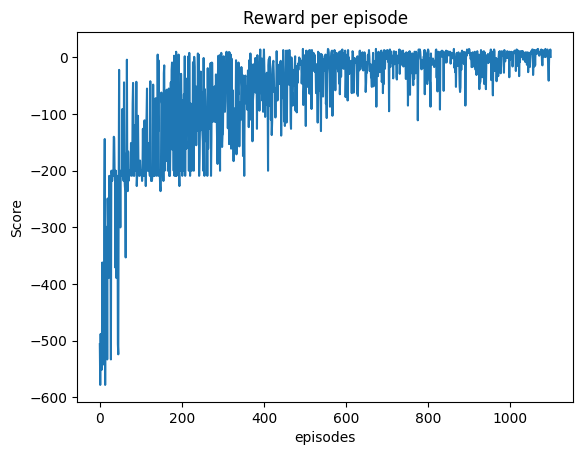

In [31]:
# Test policy.
test_episodes = 200
test_rewards = []

for _ in range(test_episodes):
    state, info = env.reset()
    done = False
    ep_reward = 0
    while not done:
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, info = env.step(action)
        ep_reward += reward
        done = terminated or truncated
    test_rewards.append(ep_reward)

print(f"Average Reward over 100 tests: {np.mean(test_rewards)}")

# Visualize
plt.plot(training_rewards)

plt.title("Reward per episode")
plt.xlabel("episodes")
plt.ylabel("Score")
plt.show()
    

At first the taxi when the score is near -600 the taxi is not drivin good its driving bad trying to pick up in the wrong spots. As we go up the agent gets better and better avoiding the penalties. When setting the the learning rate to .1 and the exploration(epsilon) to .5 the agent spends more time exploring which does not reduce the score the agent gets. The agent keeps getting penalties. Keeping the exploration at .1 we get to from -600 to about -200 in only 200 episodes which is good for the agent. 